# Pipeline de Limpieza de Datos con PySpark
Este notebook contiene un flujo profesional para el procesamiento y limpieza de datos a gran escala.

## Importación de librerías

In [1]:
import pandas as pd  # Manipulación y análisis de datos tabulares (DataFrames)
import numpy as np   # Operaciones matemáticas avanzadas y manejo de valores nulos (NaN)

## Carga de archivos

In [3]:
# 1. Carga de información
path = '/content/4. ventas_ecommerce_sucio_27072026.xlsx' #Pega aquí tu base de datos
df = pd.read_excel(path) #Aquí le das la orden de que se cargue la información
print("Pandas: Archivo cargado correctamente.") #Un print es la impresión de un texto en un código
display(df) #con display vas a poder visualizar tu base de datos

Pandas: Archivo cargado correctamente.


,ID Cliente,Nombre Completo,Email,Telefono,Fecha Nacimiento,Ciudad,Genero,ID Producto,Producto,Categoria,Precio Unitario,Cantidad,Fecha Compra,Metodo Pago,Descuento,Activo,Comentarios
0,1008,Isabella Torres,ISABELLA.TORRES261@HOTMAIL.COM,325-951-4846,1977-04-09 00:00:00,Cartagena,MASCULINO,1015,Peluche Grande,JUGUETERIA,35000,2,2023-01-01 00:00:00,PSE,20,no,NaN
1,1176,DANIELA ORTIZ,daniela.ortiz470@hotmail.com,326 4911110,1999-02-07 00:00:00,cartagena,M,1351,Teclado Mecánico,TECNOLOGIA,120000,1,2023-02-10 00:00:00,PSE,20,0,NaN
2,1167,Fernando Sanchez,fernando.sanchez740@gmail.com,(313) 962-7365,1978-06-30 00:00:00,cali,M,1333,Guantes de Gimnasio,deportes,$500.000,5.0,13-Apr-2023,Efectivo,NaN,Si,NaN
3,1173,Felipe Mendoza,felipe.mendoza369@yahoo.com,329-129-7102,1994-10-10 00:00:00,Cali,Femenino,1345,Set de Brochas,belleza,$500.000,2,04-18-2023,Efectivo,0.05,0,NaN
4,1171,Carolina Gomez,carolina.gomez516@hotmail.com,319 8436241,2000-10-03 00:00:00,Medellín,FEMENINO,1341,Muñeca Articulada,Jugueteria,$60.000,3.0,2023-10-16 00:00:00,Nequi,0,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,1105,Carlos Jimenez,CARLOS.JIMENEZ956@GMAIL.COM,3277661830,03-Aug-1989,Barranquilla,m,1212,Muñeca Articulada,jugueteria,200000,2,2024-06-12 00:00:00,Efectivo,NaN,0,NaN
372,1032,Luis Torres,luis.torres336@hotmail.com,+57 328 794 7055,1986-11-05 00:00:00,cartagena,FEMENINO,1068,Crema Facial,belleza,$ 350.000,5,2024-06-20 00:00:00,Efectivo,0.15,Si,Excelente atención
373,1014,Carlos Gonzalez,carlos.gonzalez305@outlook.com,+57 303 341 2328,1965-05-27 00:00:00,barranquilla,masculino,1026,Teclado Mecánico,Tecnologia,1200000.00,1,2024-04-09 00:00:00,Daviplata,0.0,SI,NaN
374,1099,Valentina Gomez,valentina.gomez294@hotmail.com,311-098-8138,07-22-1970,cali,m,1197,Mouse Inalámbrico,Tecnologia,500000,4,09-23-2024,PSE,15,0,NaN


## Exploración de limpieza de datos
En esta sección se realizará la limpieza de datos que se debe realizar a la base de datos

# Estandarización de nombres de columnas
## Prompt:
Revisa la tabla df, tu objetivo es implementando un código limpio sin mucha complejidad pero con buenas prácticas y entendible  para estandarizar el nombre de las columnas de la siguiente manera:
 1. convierte todas las columnas en minúsculas.
 2. quita los espacios al inicio y al final de cada columna. 3. en los espacios intermedios de una columna con un nombre compuesto como "fecha nacimiento", agrega "_" en vez de espacios.
3. Esta acción debe ser un df_1, para seguir haciendo trazabilidad a los cambios ejecutados.
4. adicional muestra una tabla resumen de como se llamaban las columnas antes y después de hacer el cambio.


In [4]:
df_1 = df.copy()

# Obtener nombres de columnas originales
original_columns = df_1.columns.tolist()

# Aplicar estandarización a los nombres de las columnas
new_columns = []
for col in original_columns:
    # 1. Convertir a minúsculas
    col = col.lower()
    # 2. Quitar espacios al inicio y al final
    col = col.strip()
    # 3. Reemplazar espacios intermedios con guiones bajos
    col = col.replace(' ', '_')
    new_columns.append(col)

df_1.columns = new_columns

print("Nombres de columnas estandarizados en df_1.")

# Crear tabla resumen de cambios en nombres de columnas
summary_columns_df = pd.DataFrame({
    'Columna Original': original_columns,
    'Columna Estandarizada': new_columns
})

print("\nTabla Resumen de Nombres de Columnas:")
display(summary_columns_df)

Nombres de columnas estandarizados en df_1.

Tabla Resumen de Nombres de Columnas:


,Columna Original,Columna Estandarizada
0,ID Cliente,id_cliente
1,Nombre Completo,nombre_completo
2,Email,email
3,Telefono,telefono
4,Fecha Nacimiento,fecha_nacimiento
5,Ciudad,ciudad
6,Genero,genero
7,ID Producto,id_producto
8,Producto,producto
9,Categoria,categoria


# Eliminación de duplicados:
## Prompt:
Revisa la tabla df_1, tu objetivo es implementando un código limpio sin mucha complejidad pero con buenas prácticas y entendible  para:

Eliminar los duplicados de la siguiente manera:
1. crear una tabla de duplicados de fila completa indicando cuantas veces se repiten.  estos registros eliminalos completamente en una tabla derivada de df_1 que se llame df_2
cuenta cuantos registros tenias antes en df_1 y cuantos ahora en df_2.

2. crea una tabla auxiliar de df_2 que se llame duplicados por id_cliente y cuentas cuantos son.
tambien cuenta cuántos son. Estos clientes duplicados solo por id_cliente crea una marca que diga duplicados y los que sean duplicados marca como "si" y los que no como "no"
3. Esta acción debe estar en  df_2, para seguir haciendo trazabilidad a los cambios ejecutados.

In [4]:
import pandas as pd
import os

# 0. Verificar y cargar el archivo
path = '/content/4. ventas_ecommerce_sucio_27072026.xlsx'

if not os.path.exists(path):
    print(f"Error: El archivo no se encuentra en {path}. Por favor súbelo.")
else:
    df = pd.read_excel(path)

    # 1. Crear df_1 con nombres estandarizados
    df_1 = df.copy()
    df_1.columns = [col.lower().strip().replace(' ', '_') for col in df_1.columns]

    # 2. Identificar y eliminar duplicados de fila completa
    duplicados_completos = df_1[df_1.duplicated(keep=False)]
    tabla_duplicados_completos = duplicados_completos.groupby(list(df_1.columns)).size().reset_index(name='repeticiones')

    # Crear df_2 eliminando los duplicados completos
    df_2 = df_1.drop_duplicates(keep=False).copy()

    print(f"Registros en df_1 (original): {len(df_1)}")
    print(f"Registros en df_2 (sin duplicados completos): {len(df_2)}")
    print("\nTabla de duplicados de fila completa:")
    display(tabla_duplicados_completos)

    # 3. Identificar duplicados por id_cliente en df_2
    conteos_id = df_2.groupby('id_cliente').size().reset_index(name='cantidad')
    duplicados_por_id_cliente = conteos_id[conteos_id['cantidad'] > 1]

    # Crear la marca en df_2
    df_2['duplicados'] = df_2['id_cliente'].isin(duplicados_por_id_cliente['id_cliente']).map({True: 'si', False: 'no'})

    print(f"\nCantidad de IDs de cliente duplicados: {len(duplicados_por_id_cliente)}")
    print("\nTabla auxiliar de duplicados por id_cliente:")
    display(duplicados_por_id_cliente)

    print("\nVista previa de df_2 con la columna 'duplicados':")
    display(df_2.head())

Registros en df_1 (original): 376
Registros en df_2 (sin duplicados completos): 352

Tabla de duplicados de fila completa:


,id_cliente,nombre_completo,email,telefono,fecha_nacimiento,ciudad,genero,id_producto,producto,categoria,precio_unitario,cantidad,fecha_compra,metodo_pago,descuento,activo,comentarios,repeticiones
0,1044,Mariana Martinez,mariana.martinez467@yahoo.com,(315) 140-1051,1968-10-03 00:00:00,Bucaramanga,Masculino,1094,Protector Solar,belleza,120000.00,3,12-23-2024,Nequi,0.15,0,-,2
1,1053,Andres Martinez,andres.martinez446@gmail.com,325 5743132,05-Apr-1988,Cartagena,M,1108,Set de Ollas,Hogar,150000,1,2023-11-12 00:00:00,PSE,0.0,True,Excelente atención,2
2,1056,Felipe Sanchez,felipe.sanchez273@hotmail.com,+57 315 223 9559,1979-09-07 00:00:00,medellin,f,1113,Set de Ollas,HOGAR,"$80,000",5,06-22-2024,Tarjeta de Crédito,15,No,Sin dato,2
3,1081,Andrea Vargas,andrea.vargas783@hotmail.com,+57 317 808 5627,1971-07-04 00:00:00,Cali,masculino,1163,Set de Ollas,hogar,"$150,000",4,2024-06-13 00:00:00,Daviplata,5,True,Demora en entrega,2
4,1085,David Rojas,david.rojas223@outlook.com,3051204618,26-Apr-1993,Medellín,F,1170,Organizador Plástico,HOGAR,"$15,000",4,2023-02-04 00:00:00,Efectivo,0.0,no,-,2
5,1096,Manuela Jimenez,manuela.jimenez427@gmail.com,310 1455616,01-Dec-1975,CALI,F,1190,Jean Slim Fit,moda,25000.00,3,2024-09-18 00:00:00,Tarjeta de Crédito,0.15,no,Demora en entrega,2
6,1150,Daniela Moreno,daniela.moreno957@hotmail.com,+57 300 650 6373,1979-03-07 00:00:00,CALI,FEMENINO,1295,Bufanda de Lana,MODA,"$80,000",4,2023-04-15 00:00:00,Nequi,0,SI,Excelente atención,2
7,1166,Julian Suarez,julian.suarez495@gmail.com,322 4090367,1961-12-17 00:00:00,Cali,femenino,1331,Crema Facial,Belleza,$ 500.000,3,2023-09-28 00:00:00,Efectivo,0,Si,Entrega puntual,2



Cantidad de IDs de cliente duplicados: 116

Tabla auxiliar de duplicados por id_cliente:


,id_cliente,cantidad
0,1001,3
4,1005,3
5,1006,3
6,1007,3
7,1008,2
...,...,...
167,1171,2
169,1173,3
171,1175,3
172,1176,3



Vista previa de df_2 con la columna 'duplicados':


,id_cliente,nombre_completo,email,telefono,fecha_nacimiento,ciudad,genero,id_producto,producto,categoria,precio_unitario,cantidad,fecha_compra,metodo_pago,descuento,activo,comentarios,duplicados
0,1008,Isabella Torres,ISABELLA.TORRES261@HOTMAIL.COM,325-951-4846,1977-04-09 00:00:00,Cartagena,MASCULINO,1015,Peluche Grande,JUGUETERIA,35000,2,2023-01-01 00:00:00,PSE,20,no,NaN,si
1,1176,DANIELA ORTIZ,daniela.ortiz470@hotmail.com,326 4911110,1999-02-07 00:00:00,cartagena,M,1351,Teclado Mecánico,TECNOLOGIA,120000,1,2023-02-10 00:00:00,PSE,20,0,NaN,si
3,1173,Felipe Mendoza,felipe.mendoza369@yahoo.com,329-129-7102,1994-10-10 00:00:00,Cali,Femenino,1345,Set de Brochas,belleza,$500.000,2,04-18-2023,Efectivo,0.05,0,NaN,si
4,1171,Carolina Gomez,carolina.gomez516@hotmail.com,319 8436241,2000-10-03 00:00:00,Medellín,FEMENINO,1341,Muñeca Articulada,Jugueteria,$60.000,3.0,2023-10-16 00:00:00,Nequi,0,True,NaN,si
5,1031,Camila Garcia,camila.garcia511@hotmail.com,318-733-9500,2004-08-14 00:00:00,CARTAGENA,m,1066,Perfume 50ml,BELLEZA,$60.000,4,02-17-2024,Tarjeta de Crédito,0.1,0,Entrega puntual,si


# Valores nulos y duplicados
## Prompt:
Revisa la tabla df_2, tu objetivo es implementando un código limpio sin mucha complejidad pero con buenas prácticas y entendible  para:

1. Detectar numeros nullos y nullos camuflados como los que obedecen a : n/a', 'na', 'null', '-', 'sin dato', 'none', '', 'nan'
2. crea una tabla resumen por nombre de columna donde cuentes a valores núlos originales y camuflados.
3. con la columna que presente mayor afectación de duplicados en los dos tipos de nullos, eliminala del dataset y crea una nueva base de datos que se llame df_3 para continuar haciendo trazabilidad a los cambios realizados


In [5]:
import pandas as pd
import numpy as np

# 1. Definir lista de nulos camuflados
nulos_camuflados_lista = ['n/a', 'na', 'null', '-', 'sin dato', 'none', '', 'nan']

# Función para identificar y contar ambos tipos de nulos
def analizar_nulos(col):
    reales = col.isnull().sum()
    # Estandarizamos a string y minúsculas para detectar los camuflados
    camuflados = col.astype(str).str.lower().str.strip().isin(nulos_camuflados_lista).sum()
    return pd.Series([reales, camuflados], index=['nulos_reales', 'nulos_camuflados'])

# 2. Generar tabla resumen
resumen_nulos = df_2.apply(analizar_nulos).T
resumen_nulos['total_nulos'] = resumen_nulos['nulos_reales'] + resumen_nulos['nulos_camuflados']

print("Tabla resumen de valores nulos:")
display(resumen_nulos.sort_values(by='total_nulos', ascending=False))

# 3. Identificar columna con mayor afectación
columna_a_eliminar = resumen_nulos['total_nulos'].idxmax()
total_afectados = resumen_nulos['total_nulos'].max()

print(f"\nLa columna con mayor afectación es '{columna_a_eliminar}' con {total_afectados} nulos encontrados.")

# Crear df_3 eliminando la columna
df_3 = df_2.drop(columns=[columna_a_eliminar]).copy()

print(f"Se ha creado df_3 (Registros: {len(df_3)}, Columnas: {len(df_3.columns)}).")
display(df_3.head())


Tabla resumen de valores nulos:


,nulos_reales,nulos_camuflados,total_nulos
comentarios,157,189,346
descuento,22,30,52
telefono,22,27,49
id_cliente,0,0,0
nombre_completo,0,0,0
email,0,0,0
genero,0,0,0
id_producto,0,0,0
fecha_nacimiento,0,0,0
ciudad,0,0,0



La columna con mayor afectación es 'comentarios' con 346 nulos encontrados.
Se ha creado df_3 (Registros: 352, Columnas: 17).


,id_cliente,nombre_completo,email,telefono,fecha_nacimiento,ciudad,genero,id_producto,producto,categoria,precio_unitario,cantidad,fecha_compra,metodo_pago,descuento,activo,duplicados
0,1008,Isabella Torres,ISABELLA.TORRES261@HOTMAIL.COM,325-951-4846,1977-04-09 00:00:00,Cartagena,MASCULINO,1015,Peluche Grande,JUGUETERIA,35000,2,2023-01-01 00:00:00,PSE,20,no,si
1,1176,DANIELA ORTIZ,daniela.ortiz470@hotmail.com,326 4911110,1999-02-07 00:00:00,cartagena,M,1351,Teclado Mecánico,TECNOLOGIA,120000,1,2023-02-10 00:00:00,PSE,20,0,si
3,1173,Felipe Mendoza,felipe.mendoza369@yahoo.com,329-129-7102,1994-10-10 00:00:00,Cali,Femenino,1345,Set de Brochas,belleza,$500.000,2,04-18-2023,Efectivo,0.05,0,si
4,1171,Carolina Gomez,carolina.gomez516@hotmail.com,319 8436241,2000-10-03 00:00:00,Medellín,FEMENINO,1341,Muñeca Articulada,Jugueteria,$60.000,3.0,2023-10-16 00:00:00,Nequi,0,True,si
5,1031,Camila Garcia,camila.garcia511@hotmail.com,318-733-9500,2004-08-14 00:00:00,CARTAGENA,m,1066,Perfume 50ml,BELLEZA,$60.000,4,02-17-2024,Tarjeta de Crédito,0.1,0,si


#Estandarización de categorias
##Prompt:
Revisa la tabla df_3, tu objetivo es implementando un código limpio sin mucha complejidad pero con buenas prácticas y entendible para:

1. Detectar variables categoricas que tengan un formato inconsistente por ejemplo: que en una columna por ejemplo:ciudad este escrita la misma palabra de diferente forma como CALI y Cali o cali. o que en la columna nombre_completo esten escrito el mismo nombre de diferente forma

2. Indica que columnas presentan estos casos y dame un ejemplo de lo que encontraste.

3. En los casos que sea posible estandarizarlos ponlos a minúscula, quita espacios innecesarios, tildes y deja las columnas limpias.

4. Crea una tabla df_4 en la que dejes la tabla df_3 con las columnas ya limpias y estandarizadas.

In [6]:
import pandas as pd
import unicodedata

# Función para normalizar texto: minúsculas, sin espacios extra y sin tildes
def normalizar_texto(texto):
    if pd.isna(texto) or not isinstance(texto, str):
        return texto
    # Quitar espacios y convertir a minúsculas
    texto = texto.strip().lower()
    # Eliminar acentos/tildes
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    return texto

# 1. Identificar columnas con posibles inconsistencias
columnas_analisis = ['nombre_completo', 'ciudad', 'genero', 'producto', 'categoria', 'metodo_pago']

print("--- Detección de Inconsistencias (Ejemplos antes de limpiar) ---")
for col in columnas_analisis:
    valores_unicos = df_3[col].unique()
    # Mostramos los primeros 5 para dar el ejemplo al usuario
    print(f"Columna '{col}': {valores_unicos[:5]}")

# 2. Aplicar la estandarización para crear df_4
df_4 = df_3.copy()

for col in columnas_analisis:
    df_4[col] = df_4[col].apply(normalizar_texto)

print("\n--- Estandarización Completada ---")
print(f"Se ha creado df_4 con {len(df_4)} registros.")

# Mostrar comparación de una columna crítica como 'ciudad' o 'genero'
print("\nEjemplo de normalización en 'genero' y 'ciudad':")
display(df_4[['genero', 'ciudad']].drop_duplicates().head(10))

# Vista previa del nuevo DataFrame
display(df_4.head())

--- Detección de Inconsistencias (Ejemplos antes de limpiar) ---
Columna 'nombre_completo': ['Isabella Torres' 'DANIELA ORTIZ' 'Felipe Mendoza' 'Carolina Gomez'
 'Camila Garcia']
Columna 'ciudad': ['Cartagena' 'cartagena' 'Cali' 'Medellín' 'CARTAGENA']
Columna 'genero': ['MASCULINO' 'M' 'Femenino' 'FEMENINO' 'm']
Columna 'producto': ['Peluche Grande' 'Teclado Mecánico' 'Set de Brochas' 'Muñeca Articulada'
 'Perfume 50ml']
Columna 'categoria': ['JUGUETERIA' 'TECNOLOGIA' 'belleza' 'Jugueteria' 'BELLEZA']
Columna 'metodo_pago': ['PSE' 'Efectivo' 'Nequi' 'Tarjeta de Crédito' 'Daviplata']

--- Estandarización Completada ---
Se ha creado df_4 con 352 registros.

Ejemplo de normalización en 'genero' y 'ciudad':


,genero,ciudad
0,masculino,cartagena
1,m,cartagena
3,femenino,cali
4,femenino,medellin
6,f,cartagena
7,femenino,barranquilla
8,masculino,barranquilla
10,m,medellin
12,f,bogota
16,femenino,bogota


,id_cliente,nombre_completo,email,telefono,fecha_nacimiento,ciudad,genero,id_producto,producto,categoria,precio_unitario,cantidad,fecha_compra,metodo_pago,descuento,activo,duplicados
0,1008,isabella torres,ISABELLA.TORRES261@HOTMAIL.COM,325-951-4846,1977-04-09 00:00:00,cartagena,masculino,1015,peluche grande,jugueteria,35000,2,2023-01-01 00:00:00,pse,20,no,si
1,1176,daniela ortiz,daniela.ortiz470@hotmail.com,326 4911110,1999-02-07 00:00:00,cartagena,m,1351,teclado mecanico,tecnologia,120000,1,2023-02-10 00:00:00,pse,20,0,si
3,1173,felipe mendoza,felipe.mendoza369@yahoo.com,329-129-7102,1994-10-10 00:00:00,cali,femenino,1345,set de brochas,belleza,$500.000,2,04-18-2023,efectivo,0.05,0,si
4,1171,carolina gomez,carolina.gomez516@hotmail.com,319 8436241,2000-10-03 00:00:00,medellin,femenino,1341,muneca articulada,jugueteria,$60.000,3.0,2023-10-16 00:00:00,nequi,0,True,si
5,1031,camila garcia,camila.garcia511@hotmail.com,318-733-9500,2004-08-14 00:00:00,cartagena,m,1066,perfume 50ml,belleza,$60.000,4,02-17-2024,tarjeta de credito,0.1,0,si


#Formateo de datos adecuado números

##Prompt:
Revisa la tabla df_4, tu objetivo es implementando un código limpio sin mucha complejidad pero con buenas prácticas y entendible para:

1. Detectar en variables que deben ser numéricas como la del precio_unitario si presentan alguna inconsistencia en su formato como "." o "$" o " " entre otras espacios innecesarios. y genera una tabla resumen para detectar cuantos registros corresponden a cada caso

2. Elimina estas inconsistencias de tal forma que quede el numero legible.

3. Formatea el dato a un tipo entero sin decimales.  

4. Crea una tabla df_5 en la que dejes la tabla df_4 con las columnas ya limpias y estandarizadas.

In [7]:
import pandas as pd
import re

# 1. Función para detectar patrones de inconsistencia
def detectar_inconsistencia(valor):
    if pd.isna(valor):
        return "nulo"
    valor_str = str(valor)
    if '$' in valor_str:
        return "contiene $"
    if '.' in valor_str and not re.match(r'^\d+\.\d{1,2}$', valor_str):
        return "contiene puntos (formato miles/error)"
    if ' ' in valor_str.strip():
        return "espacios internos"
    if not str(valor).replace('.','',1).isdigit():
        return "otros caracteres no numericos"
    return "limpio/numerico"

# Generar tabla resumen de inconsistencias antes de limpiar
resumen_precios = df_4['precio_unitario'].apply(detectar_inconsistencia).value_counts().reset_index()
resumen_precios.columns = ['tipo_inconsistencia', 'cantidad_registros']

print("Tabla resumen de inconsistencias en 'precio_unitario':")
display(resumen_precios)

# 2. Función de limpieza profunda
def limpiar_precio(valor):
    if pd.isna(valor):
        return 0
    # Convertir a string, quitar $, puntos de miles, espacios y comas
    valor_limpio = str(valor).replace('$', '').replace('.', '').replace(',', '').strip()
    # Extraer solo los dígitos en caso de que haya texto residual
    valor_limpio = re.sub(r'\D', '', valor_limpio)
    return int(valor_limpio) if valor_limpio != '' else 0

# 3. Crear df_5 y aplicar cambios
df_5 = df_4.copy()
df_5['precio_unitario'] = df_5['precio_unitario'].apply(limpiar_precio)

print(f"\nEstandarización completada. 'precio_unitario' ahora es de tipo: {df_5['precio_unitario'].dtype}")
print("Vista previa de df_5:")
display(df_5[['id_producto', 'producto', 'precio_unitario']].head())


Tabla resumen de inconsistencias en 'precio_unitario':


,tipo_inconsistencia,cantidad_registros
0,contiene $,206
1,limpio/numerico,146



Estandarización completada. 'precio_unitario' ahora es de tipo: int64
Vista previa de df_5:


,id_producto,producto,precio_unitario
0,1015,peluche grande,35000
1,1351,teclado mecanico,120000
3,1345,set de brochas,500000
4,1341,muneca articulada,60000
5,1066,perfume 50ml,60000


#Formateo de datos adecuado fechas

##Prompt:
Revisa la tabla df_5, tu objetivo es implementando un código limpio sin mucha complejidad pero con buenas prácticas y entendible para:

1. Detectar en variables que deben ser formato fecha como la del fecha_nacimiento  o fecha_compra si presentan alguna inconsistencia en su formato como que tengan numeros y letras combinadas por ejemplo 01-12-2026 o 01-dic-2026 o 01/12/2026 entre otras espacios innecesarios. y genera una tabla resumen para detectar cuantos registros corresponden a cada caso de los que encuentras.

2. Elimina estas inconsistencias de tal forma que la fecha quede en un formato estandar AAAA-mm--dden caso donde haya confusión agrega una columna "revisar_fecha" y marca con "si" las que no puedas ajustar

3. Formatea el dato a un tipo date adecuado  

4. Crea una tabla df_6 en la que dejes la tabla df_5 con las columnas ya limpias y estandarizadas.

In [8]:
import pandas as pd
import numpy as np

# 1. Función para detectar el tipo de formato/inconsistencia
def detectar_tipo_fecha(valor):
    if pd.isna(valor):
        return "nulo"
    v_str = str(valor).lower().strip()
    if any(mes in v_str for mes in ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']):
        return "texto/ingles"
    if '-' in v_str and '/' in v_str:
        return "mezcla separadores"
    if '/' in v_str:
        return "formato barra (/)"
    if '-' in v_str:
        return "formato guion (-)"
    return "otro/desconocido"

# Resumen de inconsistencias para ambas columnas
print("--- Resumen de Inconsistencias en Fechas ---")
for col in ['fecha_nacimiento', 'fecha_compra']:
    print(f"\nColumna: {col}")
    display(df_5[col].apply(detectar_tipo_fecha).value_counts())

# 2. Función de limpieza y estandarización
def estandarizar_fecha(valor):
    try:
        # to_datetime es robusto para la mayoría de formatos
        fecha = pd.to_datetime(valor, errors='coerce')
        if pd.isna(fecha):
            return valor, "si"
        return fecha.date(), "no"
    except:
        return valor, "si"

# 3. Aplicar cambios para crear df_6
df_6 = df_5.copy()
df_6['revisar_fecha'] = "no"

for col in ['fecha_nacimiento', 'fecha_compra']:
    # Aplicar la función y separar el resultado en dos series
    resultados = df_6[col].apply(estandarizar_fecha)
    df_6[col] = resultados.apply(lambda x: x[0])

    # Marcar con 'si' si alguna de las dos columnas falló
    fallos = resultados.apply(lambda x: x[1]) == "si"
    df_6.loc[fallos, 'revisar_fecha'] = "si"

# Formatear columnas finales a tipo datetime (formato date)
df_6['fecha_nacimiento'] = pd.to_datetime(df_6['fecha_nacimiento'], errors='coerce')
df_6['fecha_compra'] = pd.to_datetime(df_6['fecha_compra'], errors='coerce')

print(f"\nEstandarización completada. Se ha creado df_6 con {len(df_6)} registros.")
print(f"Registros que requieren revisión manual: {(df_6['revisar_fecha'] == 'si').sum()}")
display(df_6[['fecha_nacimiento', 'fecha_compra', 'revisar_fecha']].head())

--- Resumen de Inconsistencias en Fechas ---

Columna: fecha_nacimiento


,count
fecha_nacimiento,
formato guion (-),325
texto/ingles,27



Columna: fecha_compra


,count
fecha_compra,
formato guion (-),326
texto/ingles,26



Estandarización completada. Se ha creado df_6 con 352 registros.
Registros que requieren revisión manual: 0


,fecha_nacimiento,fecha_compra,revisar_fecha
0,1977-04-09,2023-01-01,no
1,1999-02-07,2023-02-10,no
3,1994-10-10,2023-04-18,no
4,2000-10-03,2023-10-16,no
5,2004-08-14,2024-02-17,no


#Identificación de outlayers o valores atipicos
##Prompt:

Revisa la tabla df_6, tu objetivo es implementando un código limpio sin mucha complejidad pero con buenas prácticas y entendible para:

1. Detectar en variables cuantitativas como el precio la presencia de valores atípicos, garantizando que en tu análisis estos campos sean de tipo numérico.  

2. Usa gráficas como diagramas de cajas y bigotes para determinar cuáles valores son atípicos a partir de sus rangos intercuartiles. Presenta los graficos, a nivel individual por columna.

3. Muestra un diagrama de cajas y bigotes solo para la variable precio por categoria

4. Los valores atípicos reeemplazalos por su respectivo percentil 95 de cada categoria dejando una tabla limpia de atípicos

5. crea una columna llamada "atipicos precio" en la que marques con un "reemplazado pc 95" aquellos registros que reemplazaste con ese percentil y con "sin novedad" a los que no.

4. Crea una tabla df_7 en la que dejes la tabla df_6 con las columnas ya limpias y estandarizadas.

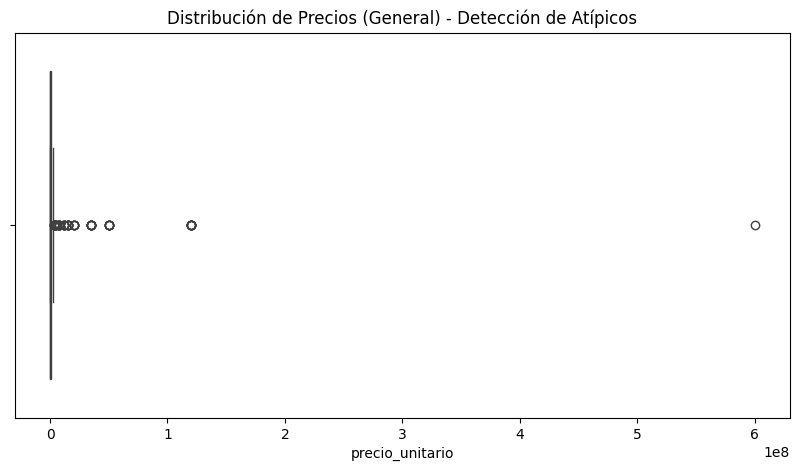

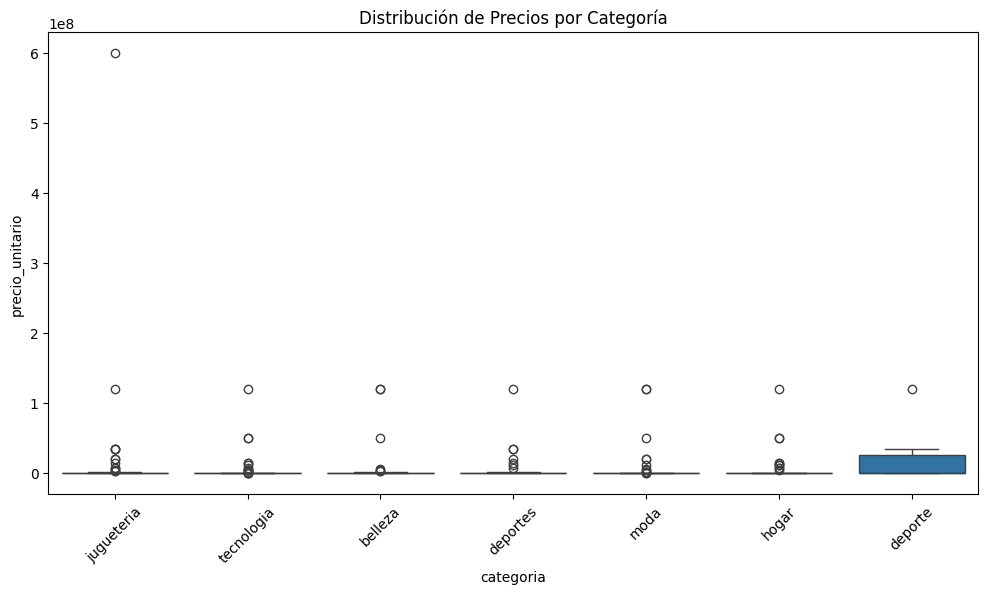


Resumen de registros tratados:


/tmp/ipykernel_3283/3426092962.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '64749999.99999997' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  group.loc[mascara_atipicos, 'precio_unitario'] = p95
/tmp/ipykernel_3283/3426092962.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '31999999.999999955' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  group.loc[mascara_atipicos, 'precio_unitario'] = p95
/tmp/ipykernel_3283/3426092962.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30749999.99999985' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  group.loc[mascara_atipicos, 'precio_unitario'] = p95
/tmp/ipykernel_

,count
atipicos_precio,
sin novedad,284
reemplazado pc 95,68



--- df_7 creado correctamente con atípicos ajustados ---


,id_cliente,nombre_completo,email,telefono,fecha_nacimiento,ciudad,genero,id_producto,producto,categoria,precio_unitario,cantidad,fecha_compra,metodo_pago,descuento,activo,duplicados,revisar_fecha,atipicos_precio
0,1008,isabella torres,ISABELLA.TORRES261@HOTMAIL.COM,325-951-4846,1977-04-09,cartagena,masculino,1015,peluche grande,jugueteria,35000.0,2,2023-01-01,pse,20,no,si,no,sin novedad
1,1176,daniela ortiz,daniela.ortiz470@hotmail.com,326 4911110,1999-02-07,cartagena,m,1351,teclado mecanico,tecnologia,120000.0,1,2023-02-10,pse,20,0,si,no,sin novedad
3,1173,felipe mendoza,felipe.mendoza369@yahoo.com,329-129-7102,1994-10-10,cali,femenino,1345,set de brochas,belleza,500000.0,2,2023-04-18,efectivo,0.05,0,si,no,sin novedad
4,1171,carolina gomez,carolina.gomez516@hotmail.com,319 8436241,2000-10-03,medellin,femenino,1341,muneca articulada,jugueteria,60000.0,3.0,2023-10-16,nequi,0,True,si,no,sin novedad
5,1031,camila garcia,camila.garcia511@hotmail.com,318-733-9500,2004-08-14,cartagena,m,1066,perfume 50ml,belleza,60000.0,4,2024-02-17,tarjeta de credito,0.1,0,si,no,sin novedad


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar que precio_unitario sea numérico en df_6
df_6['precio_unitario'] = pd.to_numeric(df_6['precio_unitario'], errors='coerce')

# 2. Visualización inicial: Boxplot general de precios
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_6['precio_unitario'])
plt.title('Distribución de Precios (General) - Detección de Atípicos')
plt.show()

# 3. Boxplot de Precios por Categoría
plt.figure(figsize=(12, 6))
sns.boxplot(x='categoria', y='precio_unitario', data=df_6)
plt.title('Distribución de Precios por Categoría')
plt.xticks(rotation=45)
plt.show()

# 4. Tratamiento de Atípicos: Reemplazo por Percentil 95 por categoría
df_7 = df_6.copy()
df_7['atipicos_precio'] = 'sin novedad'

def tratar_atipicos(group):
    q1 = group['precio_unitario'].quantile(0.25)
    q3 = group['precio_unitario'].quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr

    p95 = group['precio_unitario'].quantile(0.95)

    # Identificar atípicos
    mascara_atipicos = group['precio_unitario'] > limite_superior

    # Aplicar reemplazo y marca
    group.loc[mascara_atipicos, 'atipicos_precio'] = 'reemplazado pc 95'
    group.loc[mascara_atipicos, 'precio_unitario'] = p95
    return group

# Aplicar la lógica por cada categoría
df_7 = df_7.groupby('categoria', group_keys=False).apply(tratar_atipicos)

print("\nResumen de registros tratados:")
display(df_7['atipicos_precio'].value_counts())

print("\n--- df_7 creado correctamente con atípicos ajustados ---")
display(df_7.head())

#Reglas de validación Emails
##Prompt:

Revisa la tabla df_7, tu objetivo es implementando un código limpio sin mucha complejidad pero con buenas prácticas y entendible para:

1. Detectar a través de una expresión regular si la columna email tiene un email válido o no.

2. Genera un resumen de cuántos email válidos hay y cuantos son inválidos.

3. Genera otro resumen para saber si hay repetidos de los emails inválidos. es decir si hay algún comodín con el que se esté llenando ese campo.

4. crea una columna llamada "emails inválidos" en la que marques con un "sin email" aquellos registros que detectaste como inválidos

4. Crea una tabla df_8 en la que dejes la tabla df_7 con las columnas ya limpias y estandarizadas.

In [10]:
import pandas as pd
import re

# 1. Definir expresión regular para email válido
email_regex = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'

# 2. Detectar correos válidos/inválidos
df_8 = df_7.copy()
df_8['es_valido'] = df_8['email'].str.match(email_regex, na=False)

# Resumen de correos válidos vs inválidos
print("--- Resumen de Validación de Emails ---")
resumen_validez = df_8['es_valido'].value_counts().reset_index()
resumen_validez.columns = ['Email Válido', 'Cantidad']
display(resumen_validez)

# 3. Resumen de repetidos en correos inválidos
print("\n--- Resumen de Emails Inválidos Repetidos ---")
inválidos = df_8[df_8['es_valido'] == False]['email']
if not inválidos.empty:
    display(inválidos.value_counts().reset_index(name='repeticiones'))
else:
    print("No se encontraron emails inválidos.")

# 4. Crear columna 'emails inválidos' y marcar
df_8['emails_invalidos'] = df_8['es_valido'].map({True: 'ok', False: 'sin email'})

# Eliminar columna auxiliar de validación y mostrar resultado
df_8 = df_8.drop(columns=['es_valido'])

print(f"\nSe ha creado df_8 con {len(df_8)} registros.")
display(df_8[['nombre_completo', 'email', 'emails_invalidos']].head())

--- Resumen de Validación de Emails ---


,Email Válido,Cantidad
0,True,342
1,False,10



--- Resumen de Emails Inválidos Repetidos ---


,email,repeticiones
0,carlos.diaz940outlook.com,4
1,maria.rojas725gmail.com,2
2,gabriela.sanchez690outlook.com,2
3,daniela.torres775gmail.com,1
4,fernando.jimenez924hotmail.com,1



Se ha creado df_8 con 352 registros.


,nombre_completo,email,emails_invalidos
0,isabella torres,ISABELLA.TORRES261@HOTMAIL.COM,ok
1,daniela ortiz,daniela.ortiz470@hotmail.com,ok
3,felipe mendoza,felipe.mendoza369@yahoo.com,ok
4,carolina gomez,carolina.gomez516@hotmail.com,ok
5,camila garcia,camila.garcia511@hotmail.com,ok


#Reglas de validación edad
##Prompt:

Revisa la tabla df_8, tu objetivo es implementando un código limpio sin mucha complejidad pero con buenas prácticas y entendible para:

1. crear una columna calculada que se llame edad_actual a partir de la columna fecha_nacimiento. la cual consiste en tomar la fecha de hoy y ver cuantos años tiene el cliente a la fecha.

2. agrega otra columna calculada llamada "rango_edad" a partir de la edad con unos rangos de edad
si tiene menos de 18 años  pon menor de edad, si tiene entre 18 y 32 pon joven adulto, si tiene entre 32 y 60 años pon adulto y si tiene mas de 60 años pon "mayor a 60 años" si no se puede calcular el rango pon "inconsistente"   

3. Genera un resumen por la columna "rango_edad" para identificar cuantos registros hay de cada uno de los rangos.

4. Crea una tabla df_9 en la que dejes la tabla df_8 con las columnas ya limpias y estandarizadas.

In [11]:
from datetime import date
import pandas as pd

# 1. Función para calcular la edad actual
def calcular_edad(fecha_nac):
    if pd.isna(fecha_nac):
        return None
    hoy = date.today()
    return hoy.year - fecha_nac.year - ((hoy.month, hoy.day) < (fecha_nac.month, fecha_nac.day))

# 2. Función para determinar el rango de edad
def categorizar_edad(edad):
    if pd.isna(edad):
        return "inconsistente"
    if edad < 18:
        return "menor de edad"
    elif 18 <= edad < 32:
        return "joven adulto"
    elif 32 <= edad <= 60:
        return "adulto"
    elif edad > 60:
        return "mayor a 60 años"
    else:
        return "inconsistente"

# Aplicar lógica para crear df_9
df_9 = df_8.copy()
df_9['edad_actual'] = df_9['fecha_nacimiento'].apply(calcular_edad)
df_9['rango_edad'] = df_9['edad_actual'].apply(categorizar_edad)

# 3. Resumen por rango de edad
print("--- Resumen por Rango de Edad ---")
resumen_edad = df_9['rango_edad'].value_counts().reset_index()
resumen_edad.columns = ['Rango de Edad', 'Cantidad']
display(resumen_edad)

# 4. Mostrar vista previa
print(f"\nSe ha creado df_9 con {len(df_9)} registros y nuevas columnas de edad.")
display(df_9[['nombre_completo', 'fecha_nacimiento', 'edad_actual', 'rango_edad']].head())

--- Resumen por Rango de Edad ---


,Rango de Edad,Cantidad
0,adulto,243
1,joven adulto,71
2,mayor a 60 años,38



Se ha creado df_9 con 352 registros y nuevas columnas de edad.


,nombre_completo,fecha_nacimiento,edad_actual,rango_edad
0,isabella torres,1977-04-09,49,adulto
1,daniela ortiz,1999-02-07,27,joven adulto
3,felipe mendoza,1994-10-10,31,joven adulto
4,carolina gomez,2000-10-03,25,joven adulto
5,camila garcia,2004-08-14,22,joven adulto


### Paso Final: Limpieza Profunda y Estandarización de Campos Críticos
En esta sección se aplican las reglas de negocio finales para garantizar la integridad de emails, teléfonos, géneros y formatos numéricos.

In [12]:
import random
import re

def ajustar_telefono(tel):
    if pd.isna(tel):
        return "0000000000"
    # Dejar solo dígitos
    solo_digitos = re.sub(r'\D', '', str(tel))

    if len(solo_digitos) > 10:
        return solo_digitos[:10]
    elif len(solo_digitos) < 10:
        faltantes = 10 - len(solo_digitos)
        relleno = ''.join(str(random.choice([1, 2, 3, 4, 0])) for _ in range(faltantes))
        return solo_digitos + relleno
    return solo_digitos

def estandarizar_genero(gen):
    if not isinstance(gen, str): return gen
    g = gen.lower().strip()
    if g == 'm': return 'masculino'
    if g == 'f': return 'femenino'
    return gen

# Crear copia de trabajo
df_pre_final = df_9.copy()

# 1. Emails a minúsculas
df_pre_final['email'] = df_pre_final['email'].str.lower()

# 2. Estandarizar teléfonos
df_pre_final['telefono'] = df_pre_final['telefono'].apply(ajustar_telefono)

# 3. Estandarizar género
df_pre_final['genero'] = df_pre_final['genero'].apply(estandarizar_genero)

# 4. Precios y Cantidades a entero (si terminan en .0)
df_pre_final['precio_unitario'] = df_pre_final['precio_unitario'].astype(int)
df_pre_final['cantidad'] = pd.to_numeric(df_pre_final['cantidad'], errors='coerce').fillna(0).astype(int)

# 5. Descuento a porcentaje
df_pre_final['descuento'] = df_pre_final['descuento'].apply(lambda x: f"{int(float(x))}%" if pd.notna(x) and str(x).replace('.','',1).isdigit() else x)

# 6. Tabla de cambios relevantes para confirmación
print("--- Vista Previa de Cambios Aplicados (Muestra) ---")
cambios = df_pre_final[['email', 'telefono', 'genero', 'precio_unitario', 'cantidad', 'descuento']].head(10)
display(cambios)

print("\nPor favor, confirma si los cambios son correctos para proceder a guardar como df_10.")

--- Vista Previa de Cambios Aplicados (Muestra) ---


,email,telefono,genero,precio_unitario,cantidad,descuento
0,isabella.torres261@hotmail.com,3259514846,masculino,35000,2,20%
1,daniela.ortiz470@hotmail.com,3264911110,masculino,120000,1,20%
3,felipe.mendoza369@yahoo.com,3291297102,femenino,500000,2,0%
4,carolina.gomez516@hotmail.com,3198436241,femenino,60000,3,0%
5,camila.garcia511@hotmail.com,3187339500,masculino,60000,4,0%
6,carlos.jimenez64@yahoo.com,3036965666,femenino,150000,5,0%
7,maria.gomez721@yahoo.com,3072715518,femenino,80000,2,0%
8,david.vargas654@outlook.com,3134669254,masculino,150000,5,20%
10,mariana.mendoza349@outlook.com,3272787558,masculino,1200000,2,0%
11,diego.gomez331@outlook.com,5732529456,masculino,15000,4,0%



Por favor, confirma si los cambios son correctos para proceder a guardar como df_10.


## Finalización y Exportación de Datos
En este paso se consolida `df_10` y se exporta el archivo final limpio.

In [13]:
# 1. Definir df_10 a partir de los cambios aprobados
df_10 = df_pre_final.copy()

# 2. Exportar a CSV
file_name = 'ventas_ecommerce_limpio.csv'
df_10.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"Archivo '{file_name}' generado exitosamente.")
print(f"Dimensiones finales: {df_10.shape[0]} filas y {df_10.shape[1]} columnas.")
display(df_10.head())

Archivo 'ventas_ecommerce_limpio.csv' generado exitosamente.
Dimensiones finales: 352 filas y 22 columnas.


,id_cliente,nombre_completo,email,telefono,fecha_nacimiento,ciudad,genero,id_producto,producto,categoria,...,fecha_compra,metodo_pago,descuento,activo,duplicados,revisar_fecha,atipicos_precio,emails_invalidos,edad_actual,rango_edad
0,1008,isabella torres,isabella.torres261@hotmail.com,3259514846,1977-04-09,cartagena,masculino,1015,peluche grande,jugueteria,...,2023-01-01,pse,20%,no,si,no,sin novedad,ok,49,adulto
1,1176,daniela ortiz,daniela.ortiz470@hotmail.com,3264911110,1999-02-07,cartagena,masculino,1351,teclado mecanico,tecnologia,...,2023-02-10,pse,20%,0,si,no,sin novedad,ok,27,joven adulto
3,1173,felipe mendoza,felipe.mendoza369@yahoo.com,3291297102,1994-10-10,cali,femenino,1345,set de brochas,belleza,...,2023-04-18,efectivo,0%,0,si,no,sin novedad,ok,31,joven adulto
4,1171,carolina gomez,carolina.gomez516@hotmail.com,3198436241,2000-10-03,medellin,femenino,1341,muneca articulada,jugueteria,...,2023-10-16,nequi,0%,True,si,no,sin novedad,ok,25,joven adulto
5,1031,camila garcia,camila.garcia511@hotmail.com,3187339500,2004-08-14,cartagena,masculino,1066,perfume 50ml,belleza,...,2024-02-17,tarjeta de credito,0%,0,si,no,sin novedad,ok,22,joven adulto


In [ ]:
from google.colab import files

# Descargar el archivo final generado
files.download('ventas_ecommerce_limpio.csv')